<a href="https://colab.research.google.com/github/ShrimantiGawande/python_programming/blob/main/XG_Boost%2C_SVM%2C_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

       XGBOOST — RESULTS
Metric                 Train         Test
---------------------------------------------
R2                  0.998417     0.997759
MAE (m/s)             8.7467      10.2608
MSE                 199.7481     280.8941
RMSE (m/s)           14.1332      16.7599

Top 5 Most Important Features:
material_code             0.3307
impact_velocity_ms        0.2844
ballistic_limit_Vbl_ms    0.1856
density_kgm3              0.1115
target_thickness_mm       0.0704


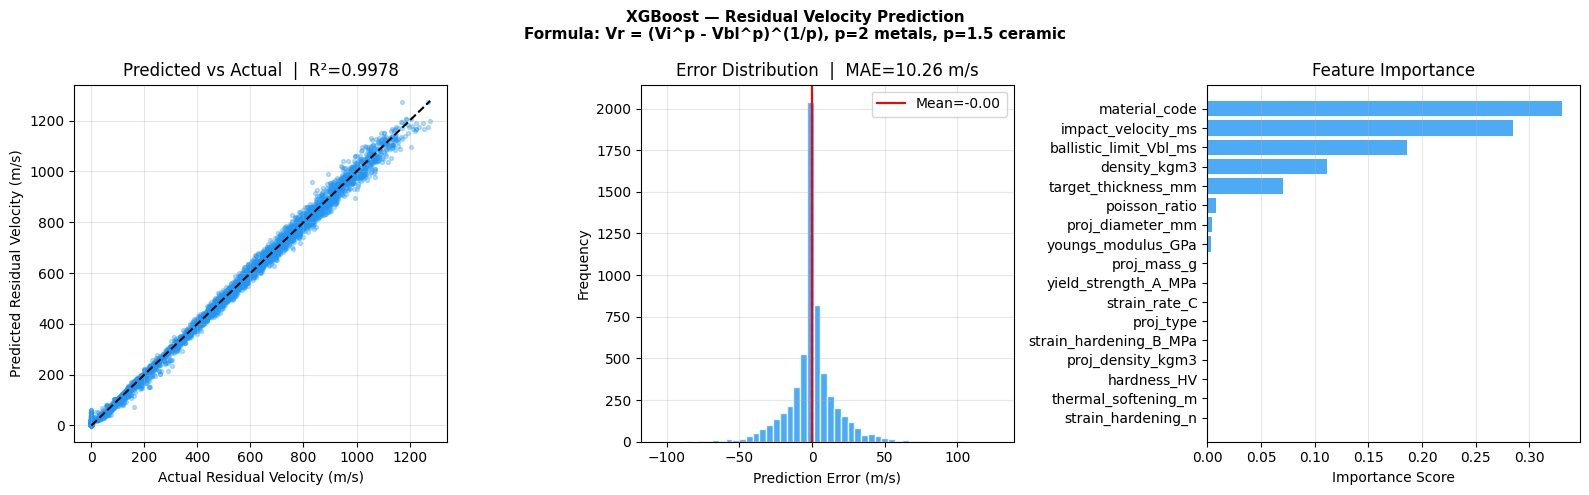

Plot saved as xgboost_results.png


In [3]:
# ============================================================
#   XGBOOST — RESIDUAL VELOCITY PREDICTION
#   Formula: Recht-Ipson  Vr = (Vi^p - Vbl^p)^(1/p)
#            p=2 for metals, p=1.5 for ceramics
# ============================================================

# Run this first in Colab if XGBoost not installed:
# !pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ---- LOAD DATA ----
# Uncomment one option below:

# Option A: Upload manually in Colab
# from google.colab import files
# files.upload()
# df = pd.read_csv('augmented_ballistic_data.csv')

# Option B: Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/augmented_ballistic_data.csv')

# Option C: Direct path
df = pd.read_csv('augmented_ballistic_data.csv')

# ---- FEATURES AND TARGET ----
FEATURES = [
    'material_code', 'density_kgm3', 'youngs_modulus_GPa',
    'poisson_ratio', 'yield_strength_A_MPa', 'strain_hardening_B_MPa',
    'strain_hardening_n', 'strain_rate_C', 'thermal_softening_m',
    'hardness_HV', 'target_thickness_mm', 'ballistic_limit_Vbl_ms',
    'proj_diameter_mm', 'proj_mass_g', 'proj_density_kgm3',
    'proj_type', 'impact_velocity_ms'
]
TARGET = 'residual_velocity_ms'

X = df[FEATURES]
y = df[TARGET]

# ---- TRAIN TEST SPLIT ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# ---- TRAIN XGBOOST ----
# No scaling needed — XGBoost is tree-based and scale-invariant
model = xgb.XGBRegressor(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    min_child_weight = 3,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0
)
model.fit(X_train, y_train)

# ---- PREDICT ----
y_pred_train = np.clip(model.predict(X_train), 0, None)
y_pred_test  = np.clip(model.predict(X_test),  0, None)

# ---- METRICS ----
r2_train  = r2_score(y_train, y_pred_train)
r2_test   = r2_score(y_test,  y_pred_test)
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test  = mean_absolute_error(y_test,  y_pred_test)
mse_train = mean_squared_error(y_train,  y_pred_train)
mse_test  = mean_squared_error(y_test,   y_pred_test)

print("=" * 45)
print("       XGBOOST — RESULTS")
print("=" * 45)
print(f"{'Metric':<15} {'Train':>12} {'Test':>12}")
print("-" * 45)
print(f"{'R2':<15} {r2_train:>12.6f} {r2_test:>12.6f}")
print(f"{'MAE (m/s)':<15} {mae_train:>12.4f} {mae_test:>12.4f}")
print(f"{'MSE':<15} {mse_train:>12.4f} {mse_test:>12.4f}")
print(f"{'RMSE (m/s)':<15} {np.sqrt(mse_train):>12.4f} {np.sqrt(mse_test):>12.4f}")
print("=" * 45)

# ---- FEATURE IMPORTANCE ----
importance = pd.Series(
    model.feature_importances_, index=FEATURES
).sort_values(ascending=False)
print("\nTop 5 Most Important Features:")
print(importance.head(5).round(4).to_string())

# ---- PLOT ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('XGBoost — Residual Velocity Prediction\n'
             'Formula: Vr = (Vi^p - Vbl^p)^(1/p), p=2 metals, p=1.5 ceramic',
             fontsize=11, fontweight='bold')

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_test, alpha=0.3, s=8, color='#2196F3')
lims = [min(y_test.min(), y_pred_test.min()),
        max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, 'k--', lw=1.5)
axes[0].set_xlabel('Actual Residual Velocity (m/s)')
axes[0].set_ylabel('Predicted Residual Velocity (m/s)')
axes[0].set_title(f'Predicted vs Actual  |  R²={r2_test:.4f}')
axes[0].grid(True, alpha=0.3)

# Error Distribution
errors = y_pred_test - y_test.values
axes[1].hist(errors, bins=50, color='#2196F3', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', lw=1.5)
axes[1].axvline(errors.mean(), color='red', lw=1.5,
                label=f'Mean={errors.mean():.2f}')
axes[1].set_xlabel('Prediction Error (m/s)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Error Distribution  |  MAE={mae_test:.2f} m/s')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Feature Importance
imp_sorted = importance.sort_values(ascending=True)
axes[2].barh(imp_sorted.index, imp_sorted.values,
             color='#2196F3', alpha=0.8)
axes[2].set_xlabel('Importance Score')
axes[2].set_title('Feature Importance')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('xgboost_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as xgboost_results.png")

     RANDOM FOREST — RESULTS
Metric                 Train         Test
---------------------------------------------
R2                  0.998418     0.997241
MAE (m/s)             8.8707      11.5953
MSE                 199.6821     345.8143
RMSE (m/s)           14.1309      18.5961

Top 5 Most Important Features:
impact_velocity_ms        0.3776
ballistic_limit_Vbl_ms    0.2094
target_thickness_mm       0.1855
proj_diameter_mm          0.0308
proj_mass_g               0.0296


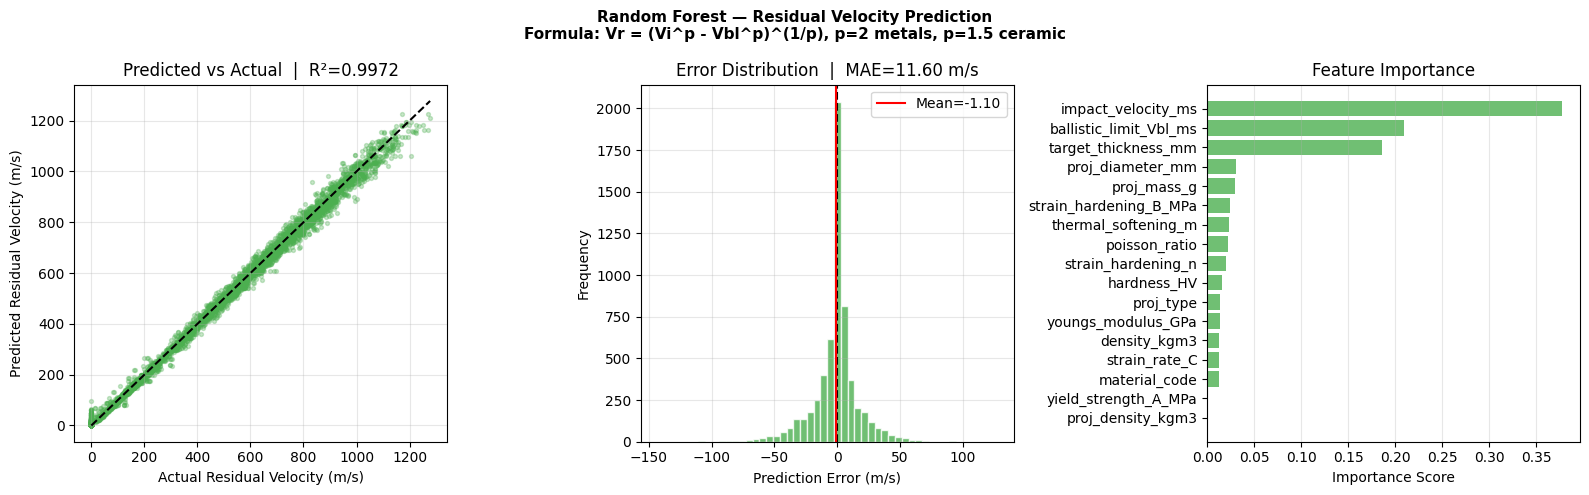

Plot saved as random_forest_results.png


In [4]:
# ============================================================
#   RANDOM FOREST — RESIDUAL VELOCITY PREDICTION
#   Formula: Recht-Ipson  Vr = (Vi^p - Vbl^p)^(1/p)
#            p=2 for metals, p=1.5 for ceramics
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ---- LOAD DATA ----
# Uncomment one option below:

# Option A: Upload manually in Colab
# from google.colab import files
# files.upload()
# df = pd.read_csv('augmented_ballistic_data.csv')

# Option B: Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/augmented_ballistic_data.csv')

# Option C: Direct path
df = pd.read_csv('augmented_ballistic_data.csv')

# ---- FEATURES AND TARGET ----
FEATURES = [
    'material_code', 'density_kgm3', 'youngs_modulus_GPa',
    'poisson_ratio', 'yield_strength_A_MPa', 'strain_hardening_B_MPa',
    'strain_hardening_n', 'strain_rate_C', 'thermal_softening_m',
    'hardness_HV', 'target_thickness_mm', 'ballistic_limit_Vbl_ms',
    'proj_diameter_mm', 'proj_mass_g', 'proj_density_kgm3',
    'proj_type', 'impact_velocity_ms'
]
TARGET = 'residual_velocity_ms'

X = df[FEATURES]
y = df[TARGET]

# ---- TRAIN TEST SPLIT ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# ---- TRAIN RANDOM FOREST ----
# No scaling needed — Random Forest is scale-invariant
model = RandomForestRegressor(
    n_estimators     = 300,
    max_depth        = None,
    min_samples_split= 5,
    min_samples_leaf = 2,
    max_features     = 'sqrt',
    random_state     = 42,
    n_jobs           = -1
)
model.fit(X_train, y_train)

# ---- PREDICT ----
y_pred_train = np.clip(model.predict(X_train), 0, None)
y_pred_test  = np.clip(model.predict(X_test),  0, None)

# ---- METRICS ----
r2_train  = r2_score(y_train, y_pred_train)
r2_test   = r2_score(y_test,  y_pred_test)
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test  = mean_absolute_error(y_test,  y_pred_test)
mse_train = mean_squared_error(y_train,  y_pred_train)
mse_test  = mean_squared_error(y_test,   y_pred_test)

print("=" * 45)
print("     RANDOM FOREST — RESULTS")
print("=" * 45)
print(f"{'Metric':<15} {'Train':>12} {'Test':>12}")
print("-" * 45)
print(f"{'R2':<15} {r2_train:>12.6f} {r2_test:>12.6f}")
print(f"{'MAE (m/s)':<15} {mae_train:>12.4f} {mae_test:>12.4f}")
print(f"{'MSE':<15} {mse_train:>12.4f} {mse_test:>12.4f}")
print(f"{'RMSE (m/s)':<15} {np.sqrt(mse_train):>12.4f} {np.sqrt(mse_test):>12.4f}")
print("=" * 45)

# ---- FEATURE IMPORTANCE ----
importance = pd.Series(
    model.feature_importances_, index=FEATURES
).sort_values(ascending=False)
print("\nTop 5 Most Important Features:")
print(importance.head(5).round(4).to_string())

# ---- PLOT ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Random Forest — Residual Velocity Prediction\n'
             'Formula: Vr = (Vi^p - Vbl^p)^(1/p), p=2 metals, p=1.5 ceramic',
             fontsize=11, fontweight='bold')

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_test, alpha=0.3, s=8, color='#4CAF50')
lims = [min(y_test.min(), y_pred_test.min()),
        max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, 'k--', lw=1.5)
axes[0].set_xlabel('Actual Residual Velocity (m/s)')
axes[0].set_ylabel('Predicted Residual Velocity (m/s)')
axes[0].set_title(f'Predicted vs Actual  |  R²={r2_test:.4f}')
axes[0].grid(True, alpha=0.3)

# Error Distribution
errors = y_pred_test - y_test.values
axes[1].hist(errors, bins=50, color='#4CAF50', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', lw=1.5)
axes[1].axvline(errors.mean(), color='red', lw=1.5,
                label=f'Mean={errors.mean():.2f}')
axes[1].set_xlabel('Prediction Error (m/s)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Error Distribution  |  MAE={mae_test:.2f} m/s')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Feature Importance
imp_sorted = importance.sort_values(ascending=True)
axes[2].barh(imp_sorted.index, imp_sorted.values,
             color='#4CAF50', alpha=0.8)
axes[2].set_xlabel('Importance Score')
axes[2].set_title('Feature Importance')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('random_forest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as random_forest_results.png")

        SVM — RESULTS
Metric                 Train         Test
---------------------------------------------
R2                  0.979378     0.979680
MAE (m/s)            30.9153      30.5408
MSE                2602.5354    2546.6437
RMSE (m/s)           51.0151      50.4643


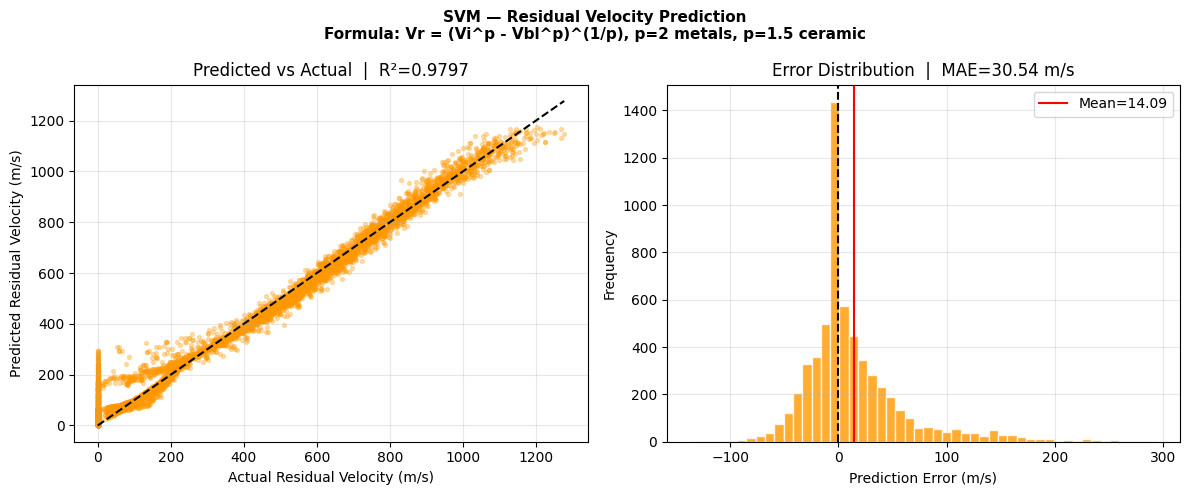

Plot saved as svm_results.png


In [5]:
# ============================================================
#   SVM — RESIDUAL VELOCITY PREDICTION
#   Formula: Recht-Ipson  Vr = (Vi^p - Vbl^p)^(1/p)
#            p=2 for metals, p=1.5 for ceramics
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ---- LOAD DATA ----
# Uncomment one option below:

# Option A: Upload manually in Colab
# from google.colab import files
# files.upload()
# df = pd.read_csv('augmented_ballistic_data.csv')

# Option B: Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/augmented_ballistic_data.csv')

# Option C: Direct path
df = pd.read_csv('augmented_ballistic_data.csv')

# ---- FEATURES AND TARGET ----
FEATURES = [
    'material_code', 'density_kgm3', 'youngs_modulus_GPa',
    'poisson_ratio', 'yield_strength_A_MPa', 'strain_hardening_B_MPa',
    'strain_hardening_n', 'strain_rate_C', 'thermal_softening_m',
    'hardness_HV', 'target_thickness_mm', 'ballistic_limit_Vbl_ms',
    'proj_diameter_mm', 'proj_mass_g', 'proj_density_kgm3',
    'proj_type', 'impact_velocity_ms'
]
TARGET = 'residual_velocity_ms'

X = df[FEATURES]
y = df[TARGET]

# ---- TRAIN TEST SPLIT ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# ---- SCALING (SVM requires scaling) ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ---- TRAIN SVM ----
model = SVR(kernel='rbf', C=100, epsilon=0.1, gamma='scale')
model.fit(X_train_scaled, y_train)

# ---- PREDICT ----
y_pred_train = np.clip(model.predict(X_train_scaled), 0, None)
y_pred_test  = np.clip(model.predict(X_test_scaled),  0, None)

# ---- METRICS ----
r2_train  = r2_score(y_train, y_pred_train)
r2_test   = r2_score(y_test,  y_pred_test)
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test  = mean_absolute_error(y_test,  y_pred_test)
mse_train = mean_squared_error(y_train,  y_pred_train)
mse_test  = mean_squared_error(y_test,   y_pred_test)

print("=" * 45)
print("        SVM — RESULTS")
print("=" * 45)
print(f"{'Metric':<15} {'Train':>12} {'Test':>12}")
print("-" * 45)
print(f"{'R2':<15} {r2_train:>12.6f} {r2_test:>12.6f}")
print(f"{'MAE (m/s)':<15} {mae_train:>12.4f} {mae_test:>12.4f}")
print(f"{'MSE':<15} {mse_train:>12.4f} {mse_test:>12.4f}")
print(f"{'RMSE (m/s)':<15} {np.sqrt(mse_train):>12.4f} {np.sqrt(mse_test):>12.4f}")
print("=" * 45)

# ---- PLOT ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('SVM — Residual Velocity Prediction\n'
             'Formula: Vr = (Vi^p - Vbl^p)^(1/p), p=2 metals, p=1.5 ceramic',
             fontsize=11, fontweight='bold')

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_test, alpha=0.3, s=8, color='#FF9800')
lims = [min(y_test.min(), y_pred_test.min()),
        max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, 'k--', lw=1.5)
axes[0].set_xlabel('Actual Residual Velocity (m/s)')
axes[0].set_ylabel('Predicted Residual Velocity (m/s)')
axes[0].set_title(f'Predicted vs Actual  |  R²={r2_test:.4f}')
axes[0].grid(True, alpha=0.3)

# Error Distribution
errors = y_pred_test - y_test.values
axes[1].hist(errors, bins=50, color='#FF9800', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', lw=1.5)
axes[1].axvline(errors.mean(), color='red', lw=1.5,
                label=f'Mean={errors.mean():.2f}')
axes[1].set_xlabel('Prediction Error (m/s)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Error Distribution  |  MAE={mae_test:.2f} m/s')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('svm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as svm_results.png")